# BioReason-Pro narrative scores — summary statistics

This notebook recomputes, **from the committed per-gene review files**, the
narrative-evaluation numbers quoted in `projects/BIOREASON_COMPARISON.md` and the
manuscript. ARGO139 is the collected RL cohort; policy exclusions are removed from
the model-performance denominator and retained in the quality audit:

- overall mean **Correctness** and **Completeness**
- Pearson and Spearman association between the independently defined axes
- input-quality and local-reference-status strata
- **Table 1** — score distribution
- **Table 2** — per-organism means
- top performers (5/5 correctness) and critical failures (1/5)
- a regenerated `per_organism_scores.png` figure

Each score is parsed directly from the `- **Correctness**: N/5` /
`- **Completeness**: N/5` lines in
`genes/<species>/<gene>/<gene>-bioreason-{rl,sft}-review.md`. Nothing is
hard-coded; re-running after adding/editing reviews updates every table.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import bioreason_stats as bs

ROOT = bs.find_repo_root()
print("repo root:", ROOT)

all_rl = bs.parse_narrative_reviews("rl", ROOT, include_excluded=True)
rl = bs.parse_narrative_reviews("rl", ROOT)
sft = bs.parse_narrative_reviews("sft", ROOT)
print(f"RL collected reviews parsed: {len(all_rl)}")
print(f"RL performance reviews:      {len(rl)}")
print(f"RL policy exclusions:        {len(rl.attrs['excluded'])}")
for row in rl.attrs["excluded"]:
    print(f"  excluded: {row['species']}/{row['gene']} ({row['exclusion_reason']})")
print(f"SFT reviews parsed: {len(sft)} (skipped: {len(sft.attrs['skipped'])})")
if sft.attrs["skipped"]:
    print("  skipped SFT files (no parseable score line):")
    for p in sft.attrs["skipped"]:
        print("   ", p)
rl.head()

repo root: /Users/cjm/worktrees/ai-gene-review-sol


RL collected reviews parsed: 139
RL performance reviews:      138
RL policy exclusions:        1
  excluded: worm/csr-1 (WRONG_INPUT_SEQUENCE)
SFT reviews parsed: 45 (skipped: 0)


,species,gene,correctness,completeness,path,expected_uniprot_id,cached_uniprot_id,reference_status,performance_included,exclusion_reason,...,interpro_input_present,interpro_input_count,interpro_input_sha256,gogpt_input_present,gogpt_input_term_count,gogpt_input_sha256,review_sha256,reference_sha256,uniprot_sha256,goa_sha256
0,9CAUD,dfrP,4,3,genes/9CAUD/dfrP/dfrP-bioreason-rl-review.md,D0VXF2,D0VXF2,DRAFT,True,,...,True,3,acfa8ac0f01870a03c30a064fb24e0e1e23e189c575c3c...,True,14,0ee9ab0cd36bc9f399c6a366008c3eb0f30d4700992909...,8c600d78f005bd8f7ee4112c3b2dd9e3aa15031e0885a2...,e319cf9467f7ade7654eaaf15b4ebdf10ba1b0a68c49d5...,4686c9737f5e671ae5874f739e0a758620a1ca235a00ee...,72ec639467f9d33b1d35e8a6b6ab0e322880d705b7c2d5...
1,AGKCO,fibrolase,2,2,genes/AGKCO/fibrolase/fibrolase-bioreason-rl-r...,P28891,P28891,COMPLETE,True,,...,True,3,1c55a515118a0172fe81385d0eb5be75178d0f3951f99b...,True,39,6caa66a0b649297d49bca928ab34d11cf2c52a93ec6bdd...,3ace73ba78c8d11d734a8bcfe9e9e8d6a8ffc0dbcb4ee9...,90b91d86bf39df2ee9bb322726d4a35f867156958fd4cb...,3d3a9db157435cbff9739c30cdca02831a0bd43be1e51f...,fbffe72c1368fa9370200eab8dd77999d49cd712af94f9...
2,ANOGA,PGRPLB,2,2,genes/ANOGA/PGRPLB/PGRPLB-bioreason-rl-review.md,F5HMW5,F5HMW5,DRAFT,True,,...,True,5,d3b01274487c3e6f2148149bfb25290379919f57040d5f...,True,100,60f4f291af24e219b145f6e3cf8e0ee7903500983c75ba...,46bb614c995501e6943d4fe5ae73540f8ce5d9de1e98ee...,720224e206c409bfe86027c686b57ade83060cc508b38e...,53f22a2052b0c03d6d0e07fd36e1bcd8d99a26520d746c...,64dbe1f3a80f2c6d652053fa048bab63211f1b8865e2d0...
3,ARATH,BRI1,5,4,genes/ARATH/BRI1/BRI1-bioreason-rl-review.md,O22476,O22476,DRAFT,True,,...,True,10,a0fdb810fb4eaa0cf4c299182f41348525eb54caad354d...,True,140,bbf5a886c36696d26d9a45f0a7247943222acea052ab8d...,34a44dad6f0d975dba34d3d1bc83556b492cda470b074a...,219fc2e5687a534a883910d37250d39abd766d033b7b93...,81b5fbd0bb60eed3376105985550f49bf94945c7b3c472...,81c508c34d35bf43b3009d58829a5ee6f8046f8b7a2f6b...
4,ARATH,COP1,5,3,genes/ARATH/COP1/COP1-bioreason-rl-review.md,P43254,P43254,DRAFT,True,,...,True,8,28ae2e5fabef2590b735ad48cc27f6aa7fd31c7e74490a...,True,94,10cbf5fe20dd57670bebf820d566893b60c165b0bfa4eb...,3da735239dde768488864a064355efb5e9f79afcaf569b...,e1d94f8e76771a32e1755a5a0d8f0491c59c9d0de54d4c...,ec50b77467a28acadb9e8a2c24757fc64f892c561f8055...,751f72c5fb6b29792085386e372235cf6aff55d6a62484...


## Overall means and axis association

All values are computed on the policy-defined performance denominator.

In [2]:
def summarise(df, label):
    return dict(
        set=label,
        n=len(df),
        correctness=round(df.correctness.mean(), 2),
        completeness=round(df.completeness.mean(), 2),
    )

overall = pd.DataFrame([summarise(rl, "RL"), summarise(sft, "SFT")])
print(overall.to_string(index=False))
print("\nRL axis association:")
print(f"  Pearson:  {rl.correctness.corr(rl.completeness, method='pearson'):.3f}")
print(f"  Spearman: {rl.correctness.rank().corr(rl.completeness.rank()):.3f}")

set   n  correctness  completeness
 RL 138         3.99          2.92
SFT  45         2.96          2.71

RL axis association:
  Pearson:  0.688
  Spearman: 0.617


## Input and reference quality strata

In [3]:
print("Input quality in the collected cohort:")
print(all_rl.input_quality.value_counts().to_string())
print("\nLocal AIGR reference status:")
print(all_rl.reference_status.value_counts().to_string())

strata = (
    rl.groupby("input_quality")
      .agg(n=("gene", "size"),
           correctness=("correctness", "mean"),
           completeness=("completeness", "mean"))
      .round(2)
)
print("\nPerformance scores by input-quality stratum:")
print(strata.to_string())

Input quality in the collected cohort:
input_quality
FULL_LENGTH_MATCH           131
TRUNCATED_AT_MODEL_LIMIT      7
WRONG_INPUT_SEQUENCE          1

Local AIGR reference status:
reference_status
COMPLETE       64
DRAFT          48
IN_PROGRESS    23
INITIALIZED     4

Performance scores by input-quality stratum:
                            n  correctness  completeness
input_quality                                           
FULL_LENGTH_MATCH         131         3.98          2.90
TRUNCATED_AT_MODEL_LIMIT    7         4.14          3.29


## Table 1 — RL score distribution (policy-defined performance set)

In [4]:
def distribution(df):
    out = pd.DataFrame(index=[5, 4, 3, 2, 1])
    for axis in ("correctness", "completeness"):
        counts = df[axis].value_counts().reindex([5, 4, 3, 2, 1], fill_value=0)
        pct = (100 * counts / len(df)).round(0).astype(int)
        out[axis] = [f"{c} ({p}%)" for c, p in zip(counts, pct)]
    out.index.name = "score"
    return out

dist = distribution(rl)
print(dist.to_string())

      correctness completeness
score                         
5        70 (51%)       1 (1%)
4        25 (18%)     40 (29%)
3        22 (16%)     51 (37%)
2        14 (10%)     39 (28%)
1          7 (5%)       7 (5%)


## Table 2 — per-organism means

Sorted by mean correctness, descending. These are descriptive selected-case summaries, not estimates of organism-level performance; case mix and input quality are confounders.

In [5]:
per_org = (
    rl.groupby("species")
      .agg(n=("gene", "size"),
           correctness=("correctness", "mean"),
           completeness=("completeness", "mean"))
      .round(1)
      .sort_values("correctness", ascending=False)
)
print(per_org.to_string())

          n  correctness  completeness
species                               
mouse    11          4.7           3.6
BACSU    13          4.5           2.9
rat      12          4.4           3.5
ARATH     3          4.3           3.3
human    19          4.3           3.3
worm     14          4.1           2.4
yeast    11          4.1           2.6
9CAUD     1          4.0           3.0
DROME     8          4.0           2.8
ECOLI    13          3.6           3.1
PSEPK     8          3.6           3.0
SCHPO    23          3.2           2.3
AGKCO     1          2.0           2.0
ANOGA     1          2.0           2.0


### Figure: descriptive per-organism correctness & completeness

Regenerated from the parsed scores and written next to this notebook. It should match the committed `article/figures/per_organism_scores.png`.

saved figures/per_organism_scores.repro.png
saved ../article/figures/per_organism_scores.png


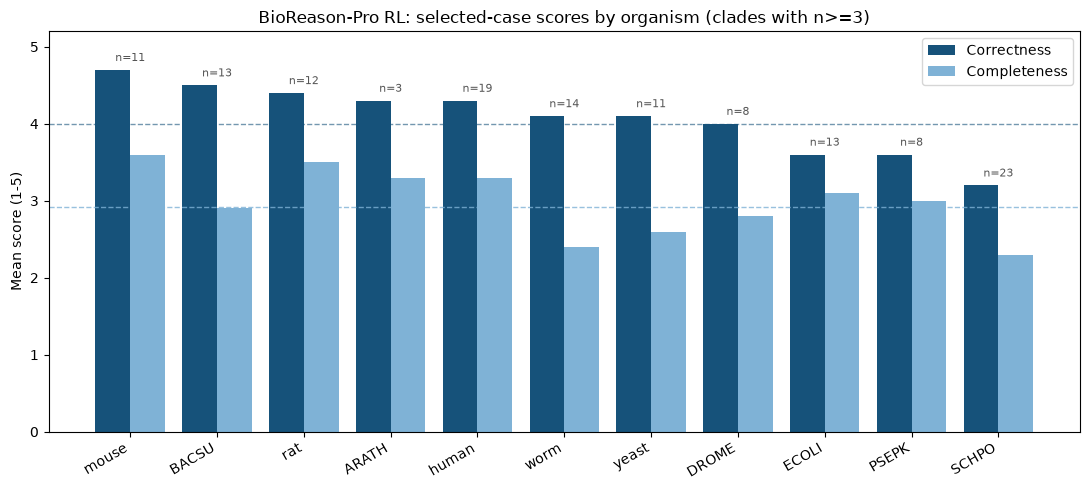

In [6]:
fig_df = per_org[per_org.n >= 3]  # mirror the manuscript figure (multi-gene clades)
x = range(len(fig_df))
w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], fig_df.correctness, width=w, label="Correctness", color="#16527a")
ax.bar([i + w/2 for i in x], fig_df.completeness, width=w, label="Completeness", color="#7fb2d6")
ax.axhline(rl.correctness.mean(), ls="--", lw=1, color="#16527a", alpha=.6)
ax.axhline(rl.completeness.mean(), ls="--", lw=1, color="#7fb2d6", alpha=.8)
for i, (sp, row) in zip(x, fig_df.iterrows()):
    ax.text(i, max(row.correctness, row.completeness) + 0.08, f"n={int(row.n)}",
            ha="center", va="bottom", fontsize=8, color="#555")
ax.set_xticks(list(x)); ax.set_xticklabels(fig_df.index, rotation=30, ha="right")
ax.set_ylim(0, 5.2); ax.set_ylabel("Mean score (1-5)")
ax.set_title("BioReason-Pro RL: selected-case scores by organism (clades with n>=3)")
ax.legend(loc="upper right")
fig.tight_layout()
outdir = Path("figures"); outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "per_organism_scores.repro.png", dpi=120)
paper_outdir = Path("../article/figures"); paper_outdir.mkdir(parents=True, exist_ok=True)
fig.savefig(paper_outdir / "per_organism_scores.png", dpi=180)
print("saved", outdir / "per_organism_scores.repro.png")
print("saved", paper_outdir / "per_organism_scores.png")
plt.show()

## Top performers and critical failures

In [7]:
top = rl[rl.correctness == 5].sort_values("completeness", ascending=False)
fails = rl[rl.correctness == 1]
print(f"Correctness 5/5: {len(top)} genes")
print(top[["species", "gene", "completeness"]].to_string(index=False))
print(f"\nCorrectness 1/5 (critical failures): {len(fails)} genes")
print(fails[["species", "gene", "completeness"]].to_string(index=False))

both5 = rl[(rl.correctness == 5) & (rl.completeness == 5)]
print(f"\nGenes scoring 5/5 on BOTH axes: {len(both5)} -> "
      f"{list(both5.gene)}  (manuscript: only Uggt1)")

Correctness 5/5: 70 genes
species    gene  completeness
    rat   Uggt1             5
  ARATH    BRI1             4
  mouse     Myc             4
  SCHPO    ura7             4
  human     APP             4
  human    EGFR             4
  human  NOTCH1             4
  human    PTEN             4
  human    TP53             4
  mouse    Akt1             4
  mouse   Calm1             4
  mouse    Egfr             4
  mouse    Pten             4
  SCHPO    gaa1             4
  mouse   Trp53             4
    rat    Akt1             4
    rat    Egfr             4
    rat   Hspa5             4
    rat   Mapk1             4
    rat    Tp53             4
   worm   cmd-1             4
   worm   lgg-1             4
  SCHPO   snx41             4
  human     MYC             4
  ECOLI    DnaJ             4
  ECOLI    SecB             4
  BACSU    amyE             4
  BACSU   spo0A             4
  SCHPO   Tim10             4
  BACSU    ftsZ             4
  PSEPK    ftsY             4
  BACSU    sec

## SFT vs RL cross-check

The SFT narrative set scores lower than RL, consistent with the paper's claim that SFT has more hallucinations.

In [8]:
sft_dist = distribution(sft)
print("SFT score distribution:")
print(sft_dist.to_string())
print()
print(pd.DataFrame([summarise(rl, "RL"), summarise(sft, "SFT")]).to_string(index=False))

SFT score distribution:
      correctness completeness
score                         
5          0 (0%)       0 (0%)
4        15 (33%)      5 (11%)
3        18 (40%)     25 (56%)
2         7 (16%)     12 (27%)
1         5 (11%)       3 (7%)

set   n  correctness  completeness
 RL 138         3.99          2.92
SFT  45         2.96          2.71
